In [245]:
import wandb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

wandb.login()
api = wandb.Api()

# === SELECT DATASET ===
DATASET = "totalseg_mri"  # Options: "totalseg_ct", "totalseg_mri", "medsegbench"

dataset_configs = {
    "medsegbench": {"patch_icl": "8imbu71v", "universeg": "5s6x367p"},
    "totalseg_mri": {"patch_icl": "wylqa8to", "universeg": "njadpkge"},
    "totalseg_ct": {"patch_icl": "hgx19apf", "universeg": "rfydytt9"},
}

runs = {k: {"wandb_name": v} for k, v in dataset_configs[DATASET].items()}
print(f"Dataset: {DATASET}")

Dataset: totalseg_mri


In [246]:
# Download artifacts and combine into single DataFrame
for run_name, run_data in runs.items():
    artifact = api.artifact(f"tidiane/patch_icl_eval/run-{run_data['wandb_name']}-per_case_dice:v0")
    artifact.download()
    table = artifact.get("per_case_dice.table.json")
    runs[run_name]["df"] = table.get_dataframe()

df_all = pd.concat([df.assign(Run=name) for name, data in runs.items() for df in [data["df"]]], ignore_index=True)
print(f"Loaded {len(df_all)} samples, {df_all['label_id'].nunique()} classes")

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Loaded 142458 samples, 56 classes


In [247]:
# Category mappings (only for TotalSeg datasets)
category_map_ct = {
    "esophagus": "Organs (Abd/Pelvis)", "stomach": "Organs (Abd/Pelvis)",
    "duodenum": "Organs (Abd/Pelvis)", "small_bowel": "Organs (Abd/Pelvis)",
    "colon": "Organs (Abd/Pelvis)", "liver": "Organs (Abd/Pelvis)",
    "gallbladder": "Organs (Abd/Pelvis)", "pancreas": "Organs (Abd/Pelvis)",
    "spleen": "Organs (Abd/Pelvis)", "kidney_left": "Organs (Abd/Pelvis)",
    "kidney_right": "Organs (Abd/Pelvis)", "urinary_bladder": "Organs (Abd/Pelvis)",
    "prostate": "Organs (Abd/Pelvis)",
    "brain": "Organs (Thorax/Head/Spine)", "atrial_appendage_left": "Organs (Thorax/Head/Spine)",
    "aorta": "Vessels", "iliac_artery_left": "Vessels", "iliac_artery_right": "Vessels",
    "superior_vena_cava": "Vessels", "inferior_vena_cava": "Vessels",
    "brachiocephalic_vein_left": "Vessels", "brachiocephalic_vein_right": "Vessels",
    "brachiocephalic_trunk": "Vessels", "iliac_vena_left": "Vessels",
    "iliac_vena_right": "Vessels", "portal_vein_and_splenic_vein": "Vessels",
    "autochthon_left": "Muscles", "autochthon_right": "Muscles",
    "iliopsoas_left": "Muscles", "iliopsoas_right": "Muscles",
}

category_map_mri = {
    **category_map_ct,
    "vertebrae": "Bones (Spine)", "intervertebral_discs": "Bones (Spine)", "sacrum": "Bones (Spine)",
    "hip_left": "Bones (Limbs/Pelvis)", "hip_right": "Bones (Limbs/Pelvis)",
    "femur_left": "Bones (Limbs/Pelvis)", "femur_right": "Bones (Limbs/Pelvis)",
}

# Apply category mapping based on dataset
if DATASET == "medsegbench":
    # MedSegBench: no category mapping, use label_id directly
    df_all['category'] = df_all['label_id']
    print("MedSegBench: using label_id as category (no grouping)")
else:
    # TotalSeg: auto-detect MRI vs CT
    labels = set(df_all['label_id'].unique())
    use_mri = bool(labels & {'vertebrae', 'intervertebral_discs', 'hip_left'})
    cat_map = category_map_mri if use_mri else category_map_ct
    df_all['category'] = df_all['label_id'].map(cat_map).fillna('Other')
    print(f"TotalSeg: using {'MRI' if use_mri else 'CT'} category map")

TotalSeg: using MRI category map


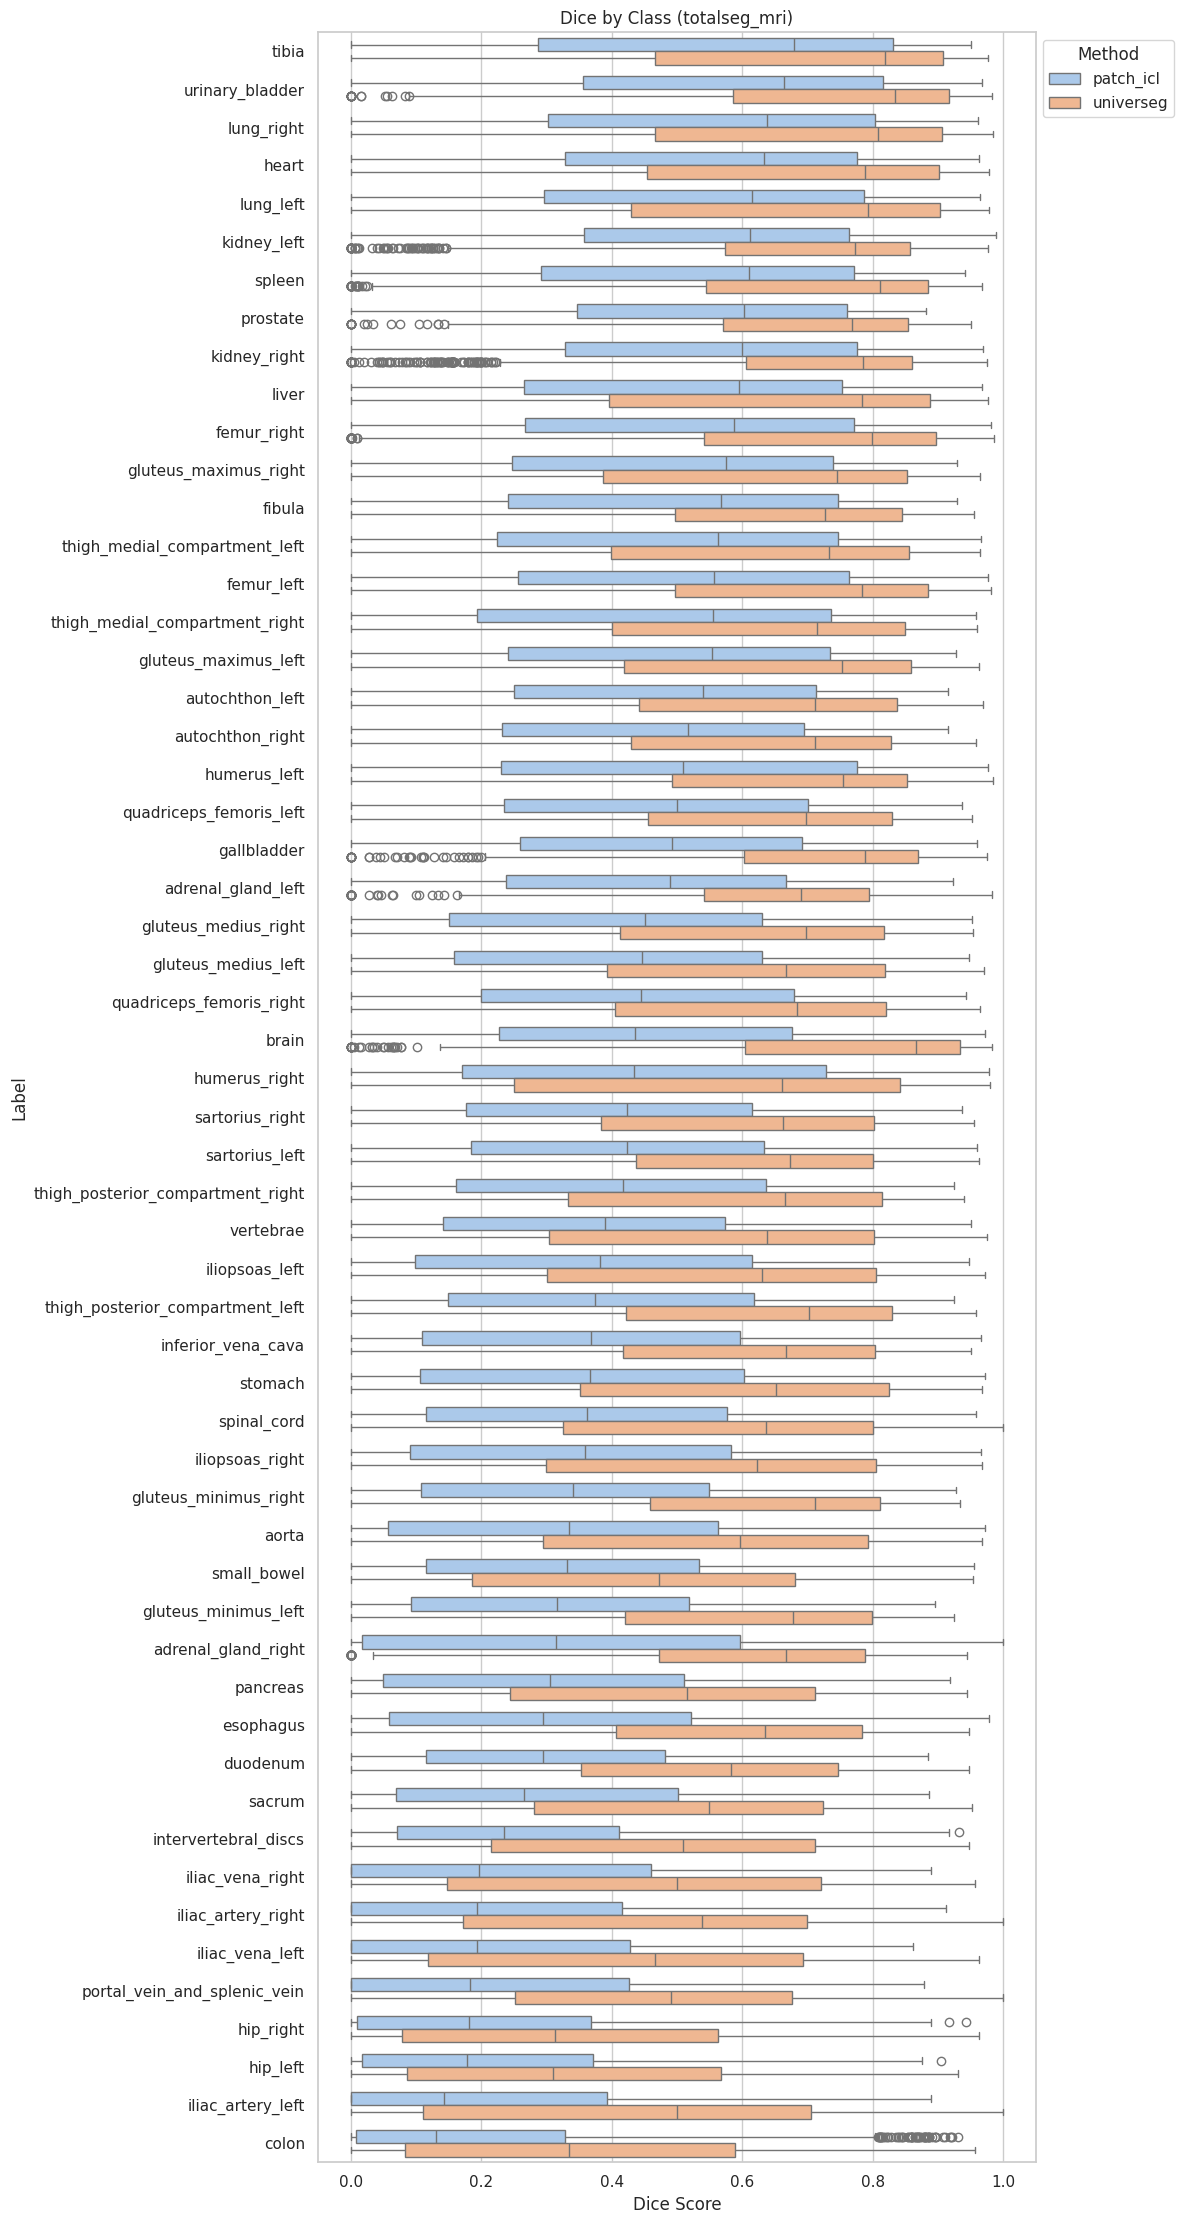

In [248]:
# Boxplot comparison
sort_order = df_all[df_all['Run'] == 'patch_icl'].groupby('label_id')['dice'].median().sort_values(ascending=False).index
df_all['label_id'] = pd.Categorical(df_all['label_id'], categories=sort_order, ordered=True)

n_classes = df_all['label_id'].nunique()
fig_height = max(8, n_classes * 0.4)

plt.figure(figsize=(12, fig_height))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_all, x="dice", y="label_id", hue="Run", orient="h", palette="pastel", width=0.7)
plt.title(f'Dice by Class ({DATASET})')
plt.xlabel('Dice Score')
plt.ylabel('Label')
plt.legend(title='Method', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [249]:
# Per-class comparison
label_stats = df_all.groupby(['Run', 'label_id'], observed=False)['dice'].mean().reset_index()
pivot = label_stats.pivot(index='label_id', columns='Run', values='dice')
pivot['diff'] = pivot['patch_icl'] - pivot['universeg']
pivot = pivot.sort_values('diff', ascending=False)

print(f"PatchICL wins: {(pivot['diff'] > 0).sum()}/{len(pivot)} classes")
print(f"Overall avg diff: {pivot['diff'].mean():+.3f}\n")
print("TOP 10 (PatchICL advantage):")
print(pivot.head(10)[['patch_icl', 'universeg', 'diff']].to_string())
print("\nBOTTOM 10 (UniverSeg advantage):")
print(pivot.tail(10)[['patch_icl', 'universeg', 'diff']].to_string())

PatchICL wins: 0/56 classes
Overall avg diff: -0.171

TOP 10 (PatchICL advantage):
Run                             patch_icl  universeg      diff
label_id                                                      
small_bowel                      0.339230   0.441619 -0.102389
tibia                            0.564910   0.670467 -0.105557
lung_right                       0.557026   0.665701 -0.108675
lung_left                        0.543919   0.652757 -0.108837
humerus_right                    0.440798   0.550055 -0.109258
heart                            0.550293   0.664221 -0.113928
hip_right                        0.221792   0.338860 -0.117068
gluteus_maximus_right            0.500319   0.622444 -0.122125
thigh_medial_compartment_right   0.483545   0.606283 -0.122738
hip_left                         0.217778   0.342324 -0.124547

BOTTOM 10 (UniverSeg advantage):
Run                    patch_icl  universeg      diff
label_id                                             
iliac_artery_right 

In [250]:
# Overall statistics
print("=" * 60)
print("OVERALL STATISTICS")
print("=" * 60)
for run_name in ['patch_icl', 'universeg']:
    scores = df_all[df_all['Run'] == run_name]['dice']
    print(f"{run_name:<12}: {scores.mean():.3f} +/- {scores.std():.3f}")

OVERALL STATISTICS
patch_icl   : 0.398 +/- 0.285
universeg   : 0.565 +/- 0.296


In [251]:
# Category summary (meaningful only for TotalSeg)
if DATASET != "medsegbench":
    cat_stats = df_all.groupby(['Run', 'category'], observed=False)['dice'].agg(['mean', 'std']).reset_index()
    cat_stats = cat_stats.sort_values(['Run', 'mean'], ascending=[True, False])
    
    print("DICE BY CATEGORY\n" + "="*60)
    for run_name, grp in cat_stats.groupby('Run'):
        print(f"\n--- {run_name} ---")
        for _, row in grp.iterrows():
            print(f"{row['category']:<35} {row['mean']:.3f} +/- {row['std']:.3f}")
else:
    cat_stats = None
    print("Category analysis skipped for MedSegBench")

DICE BY CATEGORY

--- patch_icl ---
Other                               0.454 +/- 0.286
Organs (Thorax/Head/Spine)          0.442 +/- 0.271
Muscles                             0.422 +/- 0.275
Organs (Abd/Pelvis)                 0.405 +/- 0.288
Bones (Limbs/Pelvis)                0.348 +/- 0.290
Bones (Spine)                       0.318 +/- 0.246
Vessels                             0.286 +/- 0.260

--- universeg ---
Organs (Thorax/Head/Spine)          0.708 +/- 0.317
Other                               0.613 +/- 0.286
Muscles                             0.580 +/- 0.287
Organs (Abd/Pelvis)                 0.570 +/- 0.296
Bones (Spine)                       0.505 +/- 0.288
Vessels                             0.495 +/- 0.294
Bones (Limbs/Pelvis)                0.489 +/- 0.322


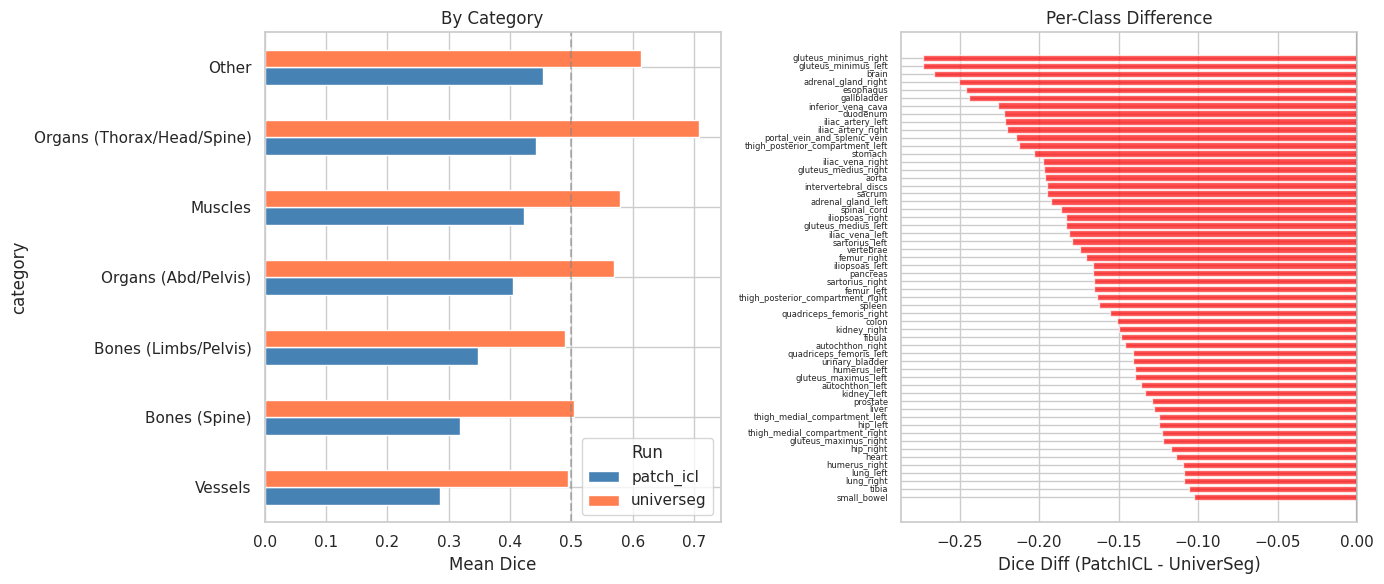

In [252]:
# Summary visualization
if DATASET != "medsegbench" and cat_stats is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Category comparison
    cat_pivot = cat_stats.pivot(index='category', columns='Run', values='mean').sort_values('patch_icl')
    cat_pivot.plot(kind='barh', ax=axes[0], color=['steelblue', 'coral'])
    axes[0].set_xlabel('Mean Dice')
    axes[0].set_title('By Category')
    axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
else:
    fig, axes = plt.subplots(1, 1, figsize=(8, 6))
    axes = [axes]  # Make it iterable

# Per-class diff (always shown)
ax = axes[-1] if len(axes) > 1 else axes[0]
diff_sorted = pivot['diff'].sort_values(ascending=False)
colors = ['green' if d > 0 else 'red' for d in diff_sorted]
ax.barh(range(len(diff_sorted)), diff_sorted.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(diff_sorted)))
ax.set_yticklabels(diff_sorted.index, fontsize=6)
ax.axvline(x=0, color='black')
ax.set_xlabel('Dice Diff (PatchICL - UniverSeg)')
ax.set_title('Per-Class Difference')

plt.tight_layout()
plt.show()

In [253]:
# Performance vs difficulty analysis
print("=" * 60)
print("PERFORMANCE VS DIFFICULTY")
print("=" * 60)

pivot_reset = pivot.reset_index()
pivot_reset['difficulty'] = pd.cut(pivot_reset['universeg'], 
                                   bins=[0, 0.3, 0.5, 0.7, 1.0],
                                   labels=['Hard (<0.3)', 'Medium (0.3-0.5)', 'Good (0.5-0.7)', 'Easy (>0.7)'])

diff_by_difficulty = pivot_reset.groupby('difficulty', observed=False).agg({
    'diff': ['mean', 'count'],
    'patch_icl': 'mean',
    'universeg': 'mean'
})

print(f"\n{'Difficulty':<20} {'N':>4} {'PatchICL':>9} {'UniverSeg':>10} {'Gap':>8}")
print("-"*55)
for diff_level in ['Hard (<0.3)', 'Medium (0.3-0.5)', 'Good (0.5-0.7)', 'Easy (>0.7)']:
    if diff_level in diff_by_difficulty.index:
        row = diff_by_difficulty.loc[diff_level]
        n = int(row[('diff', 'count')])
        if n > 0:
            pi = row[('patch_icl', 'mean')]
            us = row[('universeg', 'mean')]
            gap = row[('diff', 'mean')]
            print(f"{diff_level:<20} {n:>4} {pi:>9.3f} {us:>10.3f} {gap:>+8.3f}")

PERFORMANCE VS DIFFICULTY

Difficulty              N  PatchICL  UniverSeg      Gap
-------------------------------------------------------
Medium (0.3-0.5)       12     0.254      0.428   -0.174
Good (0.5-0.7)         41     0.444      0.611   -0.167
Easy (>0.7)             3     0.496      0.713   -0.217


In [256]:
# TotalSeg-specific analysis (ribs, vertebrae, vessels)
if DATASET.startswith("totalseg"):
    pivot_reset = pivot.reset_index()
    
    # Rib analysis (CT only - MRI doesn't have individual ribs)
    rib_data = pivot_reset[pivot_reset['label_id'].astype(str).str.contains('rib_')].copy()
    if len(rib_data) > 0:
        rib_data['rib_num'] = rib_data['label_id'].astype(str).str.extract(r'(\d+)')[0].astype(int)
        rib_by_num = rib_data.groupby('rib_num')[['patch_icl', 'universeg', 'diff']].mean()
        
        print("=" * 60)
        print("RIB ANALYSIS BY NUMBER")
        print("=" * 60)
        print(f"{'Rib#':<6} {'PatchICL':>9} {'UniverSeg':>10} {'Diff':>8}")
        print("-" * 40)
        for num, row in rib_by_num.iterrows():
            winner = "win" if row['diff'] > 0 else ""
            print(f"{num:<6} {row['patch_icl']:>9.3f} {row['universeg']:>10.3f} {row['diff']:>+8.3f} {winner}")
    
    # Vertebrae analysis (individual vertebrae for CT, grouped for MRI)
    vert_data = pivot_reset[pivot_reset['label_id'].astype(str).str.contains('vertebrae')].copy()
    if len(vert_data) > 0:
        print("\n" + "=" * 60)
        print("VERTEBRAE ANALYSIS")
        print("=" * 60)
        # Check if individual (CT) or grouped (MRI)
        if vert_data['label_id'].astype(str).str.contains('_[TLS]').any():
            # Individual vertebrae (CT): group by region
            vert_data['region'] = vert_data['label_id'].astype(str).apply(lambda x: x.split('_')[1][0])
            vert_by_region = vert_data.groupby('region')[['patch_icl', 'universeg', 'diff']].mean()
            region_names = {'L': 'Lumbar', 'S': 'Sacral', 'T': 'Thoracic'}
            print(f"{'Region':<12} {'PatchICL':>9} {'UniverSeg':>10} {'Diff':>8}")
            print("-" * 45)
            for reg in ['T', 'L', 'S']:
                if reg in vert_by_region.index:
                    row = vert_by_region.loc[reg]
                    print(f"{region_names[reg]:<12} {row['patch_icl']:>9.3f} {row['universeg']:>10.3f} {row['diff']:>+8.3f}")
        else:
            # Grouped vertebrae (MRI): show individual labels
            print(f"{'Label':<30} {'PatchICL':>9} {'UniverSeg':>10} {'Diff':>8}")
            print("-" * 60)
            for _, row in vert_data.sort_values('diff', ascending=False).iterrows():
                print(f"{row['label_id']:<30} {row['patch_icl']:>9.3f} {row['universeg']:>10.3f} {row['diff']:>+8.3f}")
    
    # Vessel analysis
    vessel_keywords = ['artery', 'vein', 'vena', 'aorta', 'portal']
    vessel_data = pivot_reset[pivot_reset['label_id'].astype(str).str.contains('|'.join(vessel_keywords), case=False)].copy()
    if len(vessel_data) > 0:
        print("\n" + "=" * 60)
        print("VESSEL ANALYSIS")
        print("=" * 60)
        print(f"{'Vessel':<35} {'PatchICL':>8} {'UniverSeg':>9} {'Diff':>7}")
        print("-" * 65)
        for _, row in vessel_data.sort_values('diff', ascending=False).iterrows():
            winner = "win" if row['diff'] > 0 else ""
            print(f"{row['label_id']:<35} {row['patch_icl']:>8.3f} {row['universeg']:>9.3f} {row['diff']:>+7.3f} {winner}")
        print(f"\nVessel avg: PatchICL {vessel_data['patch_icl'].mean():.3f} vs UniverSeg {vessel_data['universeg'].mean():.3f} (diff: {vessel_data['diff'].mean():+.3f})")
    
    # Bones analysis (MRI has hip, femur, etc.)
    bone_keywords = ['hip', 'femur', 'sacrum', 'humerus', 'tibia', 'fibula']
    bone_data = pivot_reset[pivot_reset['label_id'].astype(str).str.contains('|'.join(bone_keywords), case=False)].copy()
    if len(bone_data) > 0:
        print("\n" + "=" * 60)
        print("BONES ANALYSIS")
        print("=" * 60)
        print(f"{'Bone':<30} {'PatchICL':>8} {'UniverSeg':>9} {'Diff':>7}")
        print("-" * 60)
        for _, row in bone_data.sort_values('diff', ascending=False).iterrows():
            winner = "win" if row['diff'] > 0 else ""
            print(f"{row['label_id']:<30} {row['patch_icl']:>8.3f} {row['universeg']:>9.3f} {row['diff']:>+7.3f} {winner}")
        print(f"\nBones avg: PatchICL {bone_data['patch_icl'].mean():.3f} vs UniverSeg {bone_data['universeg'].mean():.3f} (diff: {bone_data['diff'].mean():+.3f})")
    
    if len(rib_data) == 0 and len(vert_data) == 0 and len(vessel_data) == 0 and len(bone_data) == 0:
        print("No structure-specific patterns found in labels")
else:
    print("TotalSeg-specific analysis skipped for MedSegBench")


VERTEBRAE ANALYSIS
Label                           PatchICL  UniverSeg     Diff
------------------------------------------------------------
vertebrae                          0.375      0.549   -0.174

VESSEL ANALYSIS
Vessel                              PatchICL UniverSeg    Diff
-----------------------------------------------------------------
iliac_vena_left                        0.244     0.425  -0.181 
aorta                                  0.337     0.533  -0.196 
iliac_vena_right                       0.253     0.451  -0.198 
portal_vein_and_splenic_vein           0.238     0.453  -0.214 
iliac_artery_right                     0.236     0.457  -0.220 
iliac_artery_left                      0.216     0.437  -0.221 
inferior_vena_cava                     0.366     0.592  -0.226 

Vessel avg: PatchICL 0.270 vs UniverSeg 0.478 (diff: -0.208)

BONES ANALYSIS
Bone                           PatchICL UniverSeg    Diff
------------------------------------------------------------
tibia 